In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
import matplotlib.cm as cm
colormap = cm.turbo
%matplotlib inline

# Warren's specific setup. Please comment out or delete otherwise.
CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
ProdTag = 'CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2.'

We choose just one series to analyze, since pulling in lots of raw pulses can require a lot of memory

In [3]:
# Use in place of next cell if data catalog is acting up

#TAMU HPRC
#filepath = np.sort(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/CDMS/CUTE/R37/Processed/Tests/{ProdTag}/Submerged/{ProdTag}_23231216_211119.root'))

#cedar
#filepath = np.sort(glob.glob(f'/project/6049244/data/CDMS/CUTE/R37/Processed/Tests/{ProdTag}/Submerged/{ProdTag}_23231216_211119.root'))

#narval
filepath = np.sort(glob.glob(f'/lustre06/project/6035200/perry/CUTE_R37/Submerged/{ProdTag}_23231216_211119.root'))

det = 1 # detector number
df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [4]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [5]:
RQs = (["SeriesNumber", "PTOFamps", "EventNumber", "EventTime", "EventTriggerID"] + 
       ['P' + label + 'S' + sequence + 'OFamps' for sequence in ['1', '2'] for label in ['A', 'B', 'C', 'D', 'E', 'F']])
df_rqs = df_filtered.AsNumpy(RQs)

 First look at PTOFamps spectrum from series 23231216_211119

Text(0, 1, 'Count / $\\mathrm{\\mu A}$')

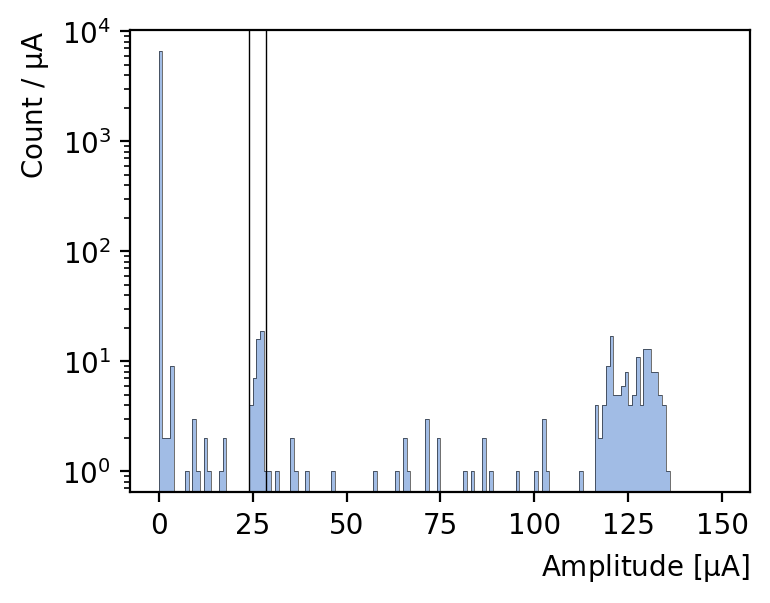

In [6]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 150, 151), alpha = 1, color = '#A1BCE5')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(0, 150, 151), histtype='step', color = 'black', lw = 0.2)
plt.axvline(24, 0, 1, lw = 0.5, color = 'black')
plt.axvline(28.5, 0, 1, lw = 0.5, color = 'black')
plt.yscale('log')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / $\mathrm{\mu A}$")

Text(0, 1, 'Count / (0.2 $\\mathrm{\\mu A}$)')

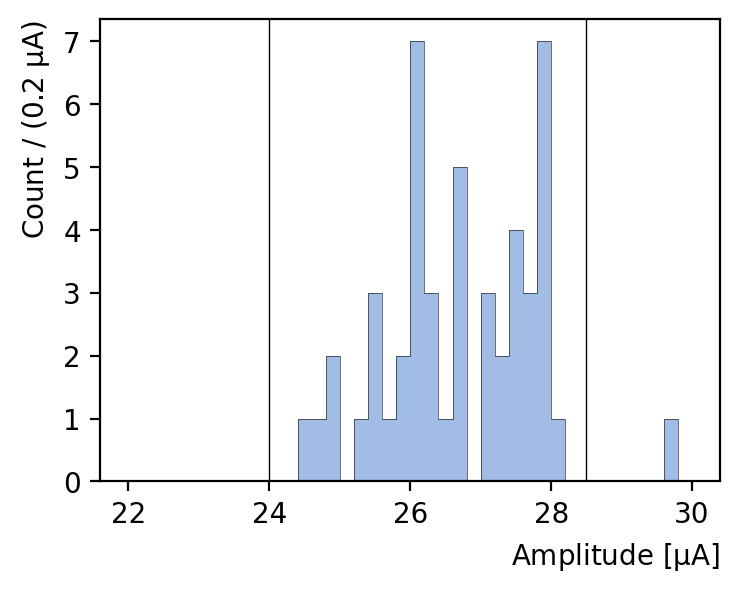

In [7]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(22, 30, 41), alpha = 1, color = '#A1BCE5')
plt.hist(df_rqs['PTOFamps']*1e6, bins=np.linspace(22, 30, 41), histtype='step', color = 'black', lw = 0.2)
plt.axvline(24, 0, 1, lw = 0.5, color = 'black')
plt.axvline(28.5, 0, 1, lw = 0.5, color = 'black')
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.2 $\mathrm{\mu A}$)")

## Pulse Shapes from CUTE data

We now look at events which are in the K shell peak so that we know their recoil energy is ~10.3 keV.

In [8]:
Kshell_eventNums = df_rqs['EventTriggerID'][(df_rqs['PTOFamps'] >= 24e-6) & (df_rqs['PTOFamps'] <= 28.5e-6)]

In [9]:
# TAMU HPRC
#rawfilepath = np.sort(glob.glob(f'/scratch/user/perry5334/samples/CUTE_R37/Raw/23231216_211119/23231216_211119_F00??.root'))

# Cedar
#rawfilepath = np.sort(glob.glob(f'/project/6049244/perry/CUTE_R37/Raw/23231216_211119/23231216_211119_F00??.root'))

# Narval
rawfilepath = np.sort(glob.glob(f'/lustre06/project/6035200/perry/CUTE_R37/Raw/23231216_211119/23231216_211119_F00??.root'))

raw_df = CDataFrame("pulses", rawfilepath)

In [10]:
eventMask = '|'.join(["(TriggerID==" + str(i) + ")" for i in Kshell_eventNums])
pulses = raw_df.Filter(eventMask).Filter('DetNum==1').AsNumpy(['TriggerID', 'ChanName', 'Pulse'])

In [11]:
pulses['Pulse'] = np.array([i - np.mean(i[:15000]) for i in pulses['Pulse']]) # subtract baseline from pulses
pulses['PT'] = np.array([np.sum(pulses['Pulse'][pulses['TriggerID'] == event], axis = 0) for event in np.unique(pulses['TriggerID'])]) # Calculate PT pulse for each event
pulses['PTavg'] = np.sum(pulses['PT'], axis=0) # Calculate "Template" PT pulse shape
pulses['PTavg'] /= max(pulses['PTavg']) # Normalize template

In [12]:
def chanPulses(trace, chanName): # function for plotting channel pulses of just one event
    colors = [colormap(i / 12) for i in range(12)] # Unique colors for pulses
    maxIndex = trace[0].tolist().index(max(trace[0])) # time bin where pulse is at maximum
    
    fig, ax = plt.subplots(1, 2, figsize=(5*2, 2*2), dpi = 400)  # 1 row, 2 columns

    for i in range(12):
        ax[0].plot(trace[i], label = chanName[i], color = colors[i])
        ax[1].plot(trace[i], label = chanName[i], color = colors[i])
        
    ax[0].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
    ax[0].set_ylabel(r"Amplitude [$\mathrm{\mu A}$]")
    ax[0].legend(fontsize = 8, ncol = 2)
    ax[0].set_xlim(maxIndex - 100, maxIndex + 1000)

    ax[1].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
    ax[1].set_ylabel(r"Amplitude [$\mathrm{\mu A}$]")
    ax[1].legend(fontsize = 8, ncol = 2)
    ax[1].set_yscale('log')
    ax[1].set_xlim(maxIndex - 100, maxIndex + 2000)
    ax[1].set_ylim(max(trace[0]) * 0.001, None) # set lower y-axis bound by fraction of peak height. Adjust as needed.

    fig.suptitle(f'Channel by Channel Pulses', fontsize=16)

    plt.tight_layout()

In [13]:
def PTPulses(PT):
    colors = [colormap(i / 12) for i in range(12)]
    maxIndex = PT[0].tolist().index(max(PT[0])) # time bin where pulse is at maximum
    
    fig, ax = plt.subplots(1, 2, figsize=(5*2, 2*2), dpi = 400)  # 1 row, 2 columns

    for i, trace in enumerate(PT):
        ax[0].plot(trace, color = colors[i % 12])
        ax[1].plot(trace, color = colors[i % 12])
        
    ax[0].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
    ax[0].set_ylabel(r"Amplitude [$\mathrm{\mu A}$]")
    ax[0].set_xlim(maxIndex - 100, maxIndex + 1000)

    ax[1].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
    ax[1].set_ylabel(r"Amplitude [ln($\mathrm{\mu A}$)]")
    ax[1].set_yscale('log')
    ax[1].set_xlim(maxIndex - 100, maxIndex + 2000)
    ax[1].set_ylim(max(PT[0]) * 0.001, None) # set lower y-axis bound by fraction of peak height. Adjust as needed.

    fig.suptitle(f'PT pulses for all events', fontsize=16)

    plt.tight_layout()

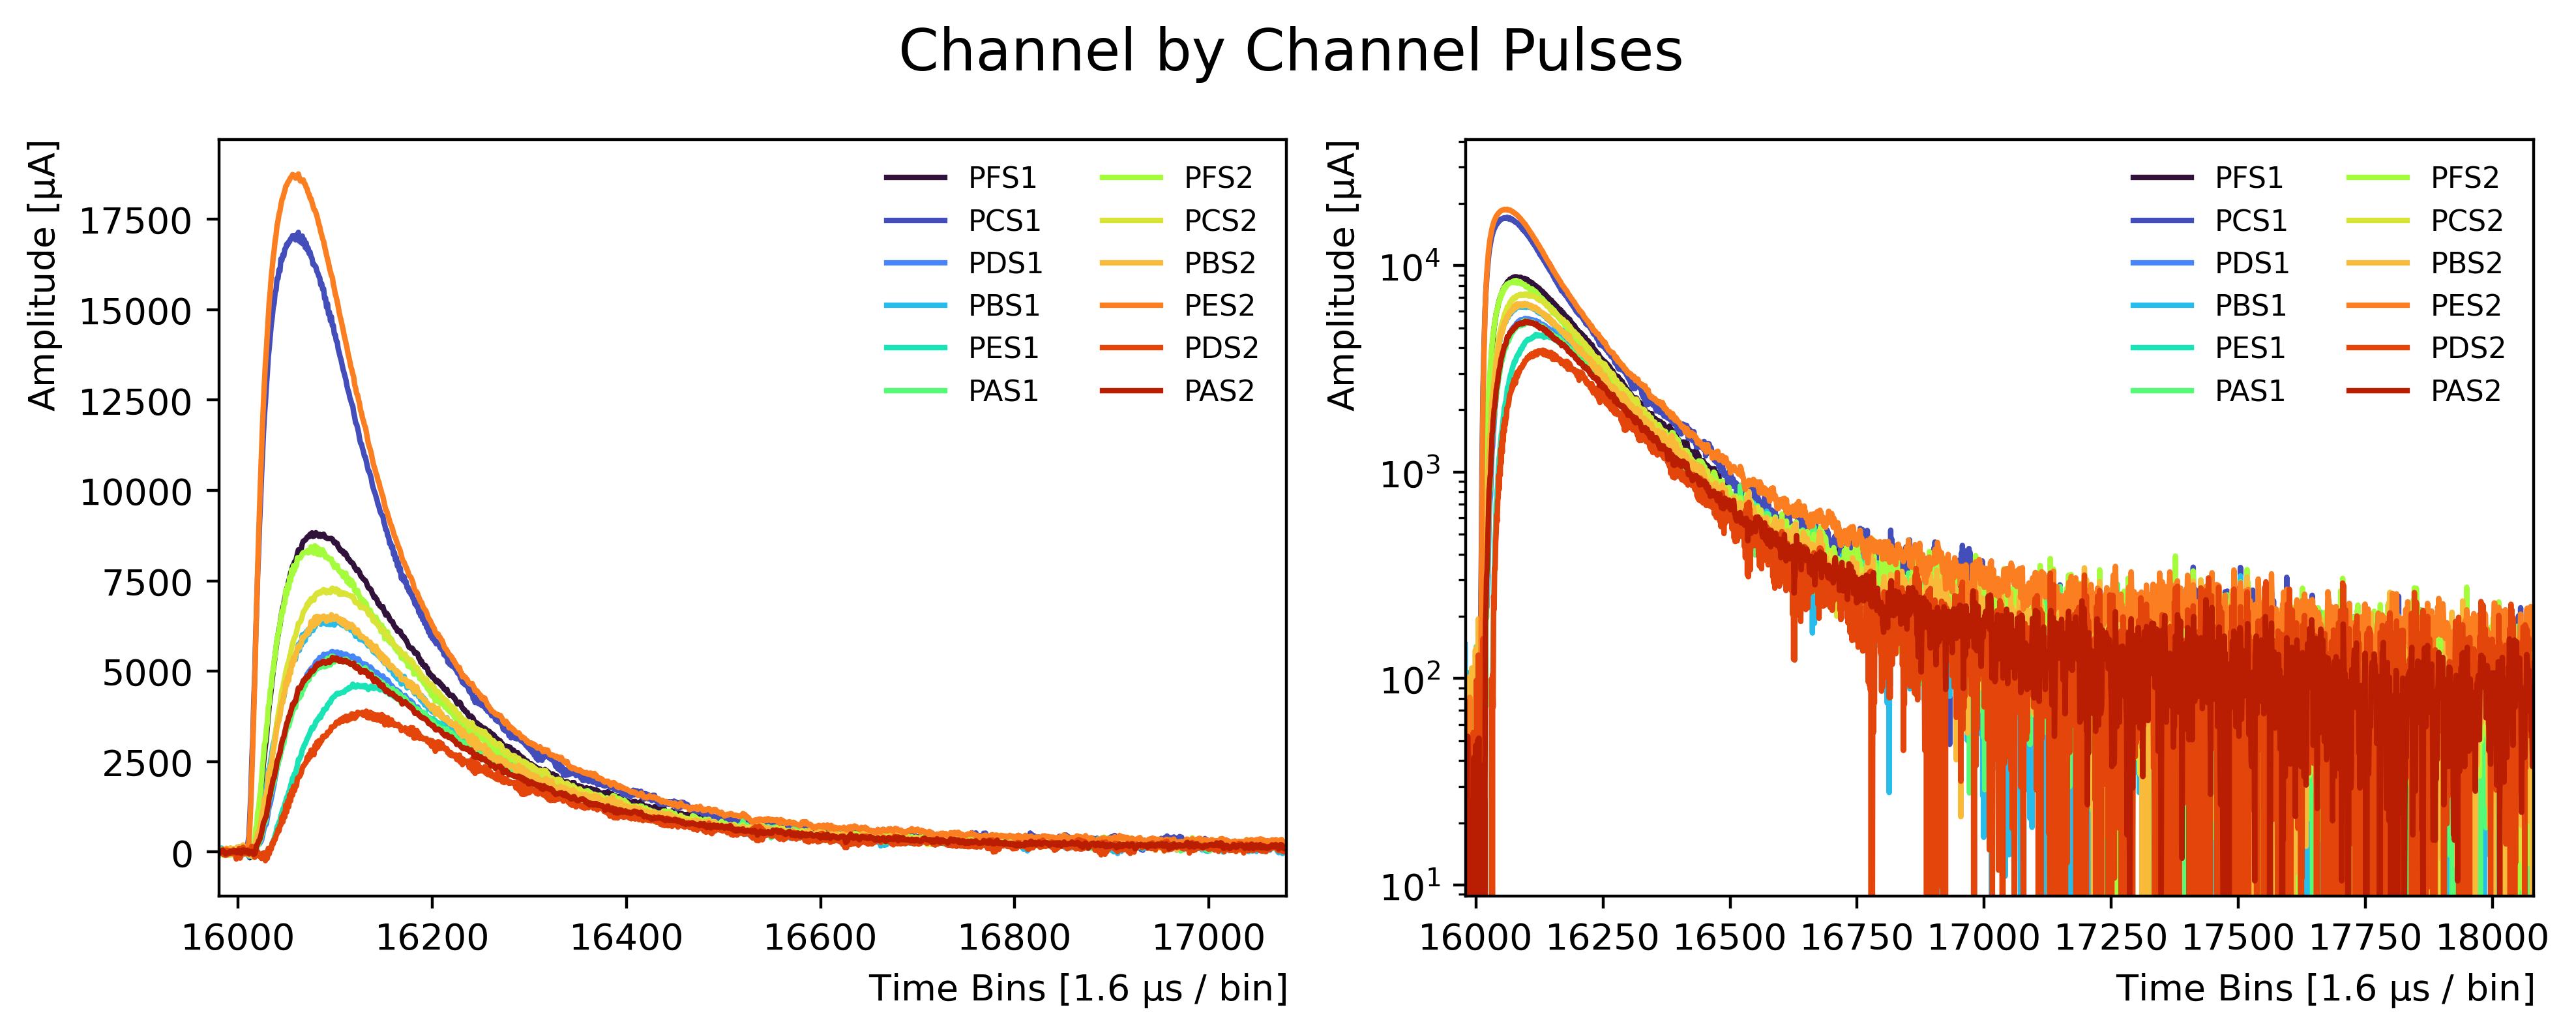

In [14]:
# Let's look at the individual channel pulses of the first K shell event
event = Kshell_eventNums[0]
eventCut = pulses['TriggerID']==event

chanPulses(pulses['Pulse'][eventCut], pulses['ChanName'][eventCut])

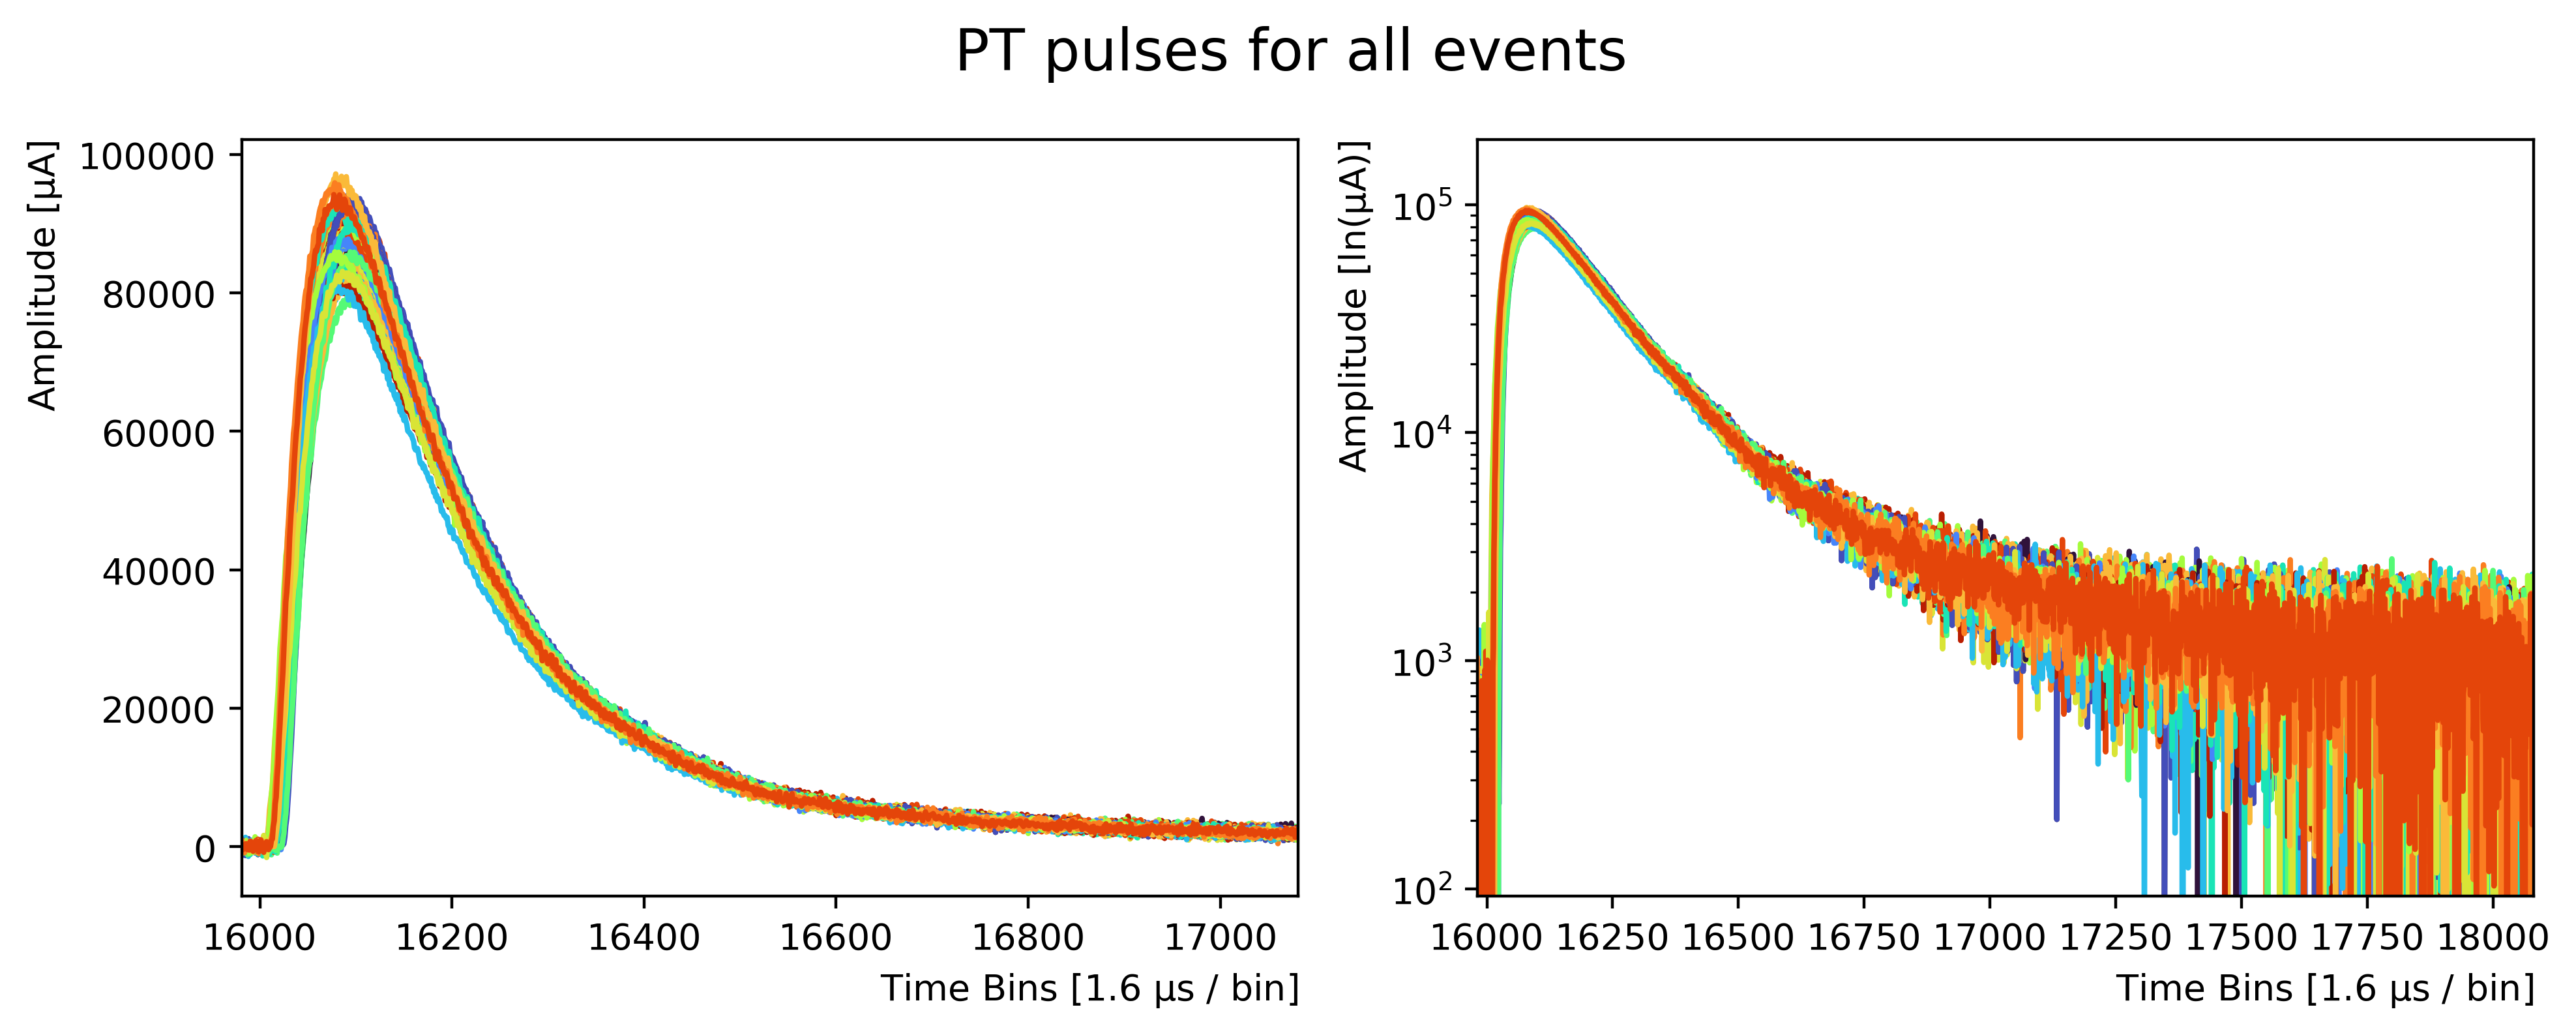

In [15]:
# Let's look at the PT pulse for all events in the K-shell peak
PTPulses(pulses['PT'])

Now let's look at the average PT pulse (what we'll call the "template") and measure the rise and two fall-times. Comparing these measurements to those from the simulation can tell use, quantitatively, how close the pulse shapes are.

In [16]:
colors = ['#3D6CA5', '#92C0DC', '#F9965C', '#D72B22']

In [17]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

/tmp/ipykernel_2442248/2773355755.py:7: RuntimeWarning: invalid value encountered in log
  a, da, b, db = fit_logPulse(time, np.log(pulses['PTavg']), t_range[0], t_range[1])


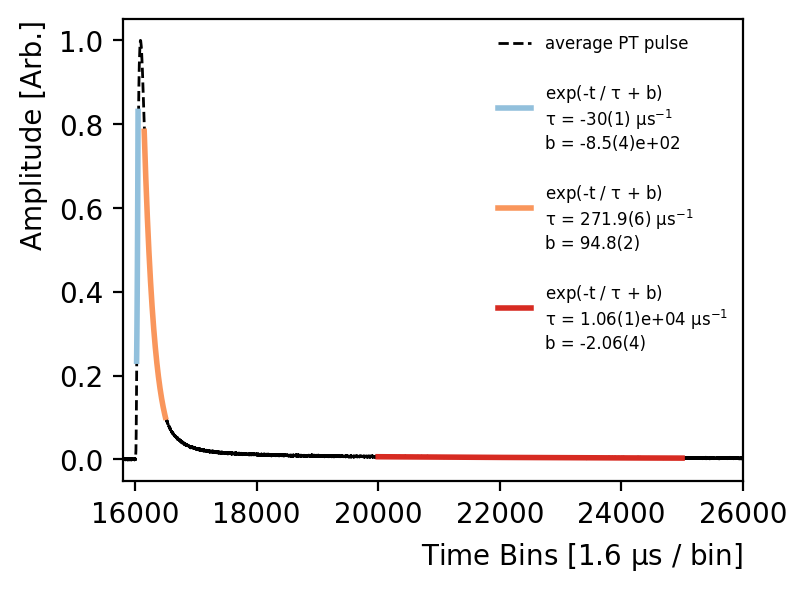

In [18]:
plt.figure(figsize=(4,3), dpi=200)
time = np.arange(0, 32768, 1)

plt.plot(pulses['PTavg'], color = 'black', ls = '--', lw = 1, label = 'average PT pulse')

for i, t_range in enumerate([(16025, 16050), (16150, 16500), (20000, 25000)]): # fit to three sections of the average PT pulse (or "Template")
    a, da, b, db = fit_logPulse(time, np.log(pulses['PTavg']), t_range[0], t_range[1])
    
    plt.plot(time[t_range[0]:t_range[1]], np.exp(func(time[t_range[0]:t_range[1]], a, b)), color = colors[1 + i], lw = 2,
         label = ('\n' + r'exp(-t / $\mathrm{\tau}$ + b)' + '\n' + 
                  r'$\mathrm{\tau}$' + ' = ' + f'{ufloat(-1.6 / a, 1.6 * da / a**2):.1uS} ' + r'$\mathrm{\mu s^{-1}}$' + '\n' + 
                   'b = ' + f'{ufloat(b, db):.1uS}'))

plt.xlim(15800, 26000)
plt.xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
plt.ylabel('Amplitude [Arb.]')
plt.legend(fontsize = 6, loc = 'upper right')

/tmp/ipykernel_2442248/1492670748.py:3: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(pulses['PTavg']), color = 'black', ls = '--', lw = 1, label = 'average PT pulse')
/tmp/ipykernel_2442248/1492670748.py:6: RuntimeWarning: invalid value encountered in log
  a, da, b, db = fit_logPulse(time, np.log(pulses['PTavg']), t_range[0], t_range[1])


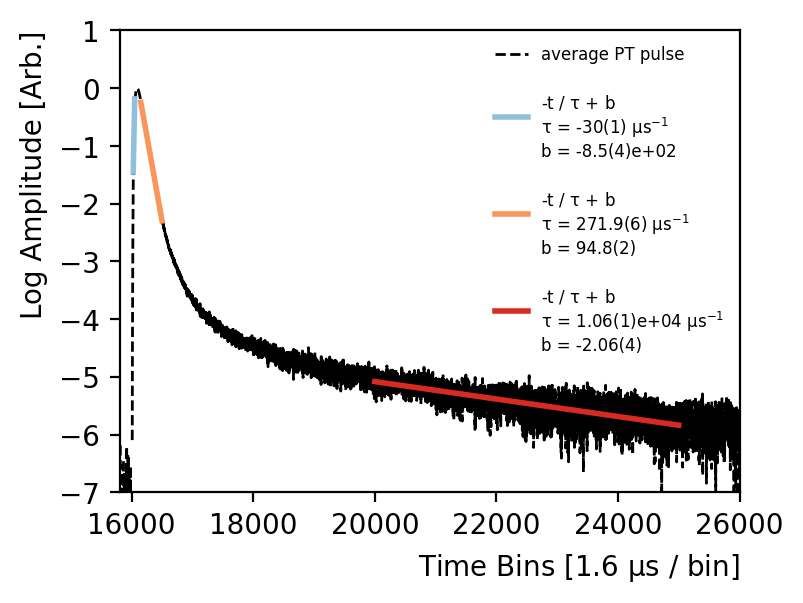

In [19]:
plt.figure(figsize=(4,3), dpi=200)

plt.plot(np.log(pulses['PTavg']), color = 'black', ls = '--', lw = 1, label = 'average PT pulse')

for i, t_range in enumerate([(16025, 16050), (16150, 16500), (20000, 25000)]):
    a, da, b, db = fit_logPulse(time, np.log(pulses['PTavg']), t_range[0], t_range[1])
    
    plt.plot(time[t_range[0]:t_range[1]], func(time[t_range[0]:t_range[1]], a, b), color = colors[1 + i], lw = 2,
         label = ('\n' + r'-t / $\mathrm{\tau}$ + b' + '\n' + 
                  r'$\mathrm{\tau}$' + ' = ' + f'{ufloat(-1.6 / a, 1.6 * da / a**2):.1uS} ' + r'$\mathrm{\mu s^{-1}}$' + '\n' + 
                   'b = ' + f'{ufloat(b, db):.1uS}'))

plt.xlim(15800, 26000)
plt.ylim(-7, 1)
plt.xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
plt.ylabel('Log Amplitude [Arb.]')
plt.legend(fontsize = 6, loc = 'upper right')

## Pulse Shapes from Simulated data

Now want to look at the same PT pulses with simulation. Starting with nominal configuration.

In [63]:
def getTES(DMCfiles, mask):
    # TESSim information is stored in 'G4SimDir/g4dmcTES' tree in the DMC file. Let's store the 'Trace' field.
    g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', DMCfiles)
    
    if mask != 0:
        TESSim = g4dmcTES.Filter('DataType==0').Filter(mask).AsNumpy(['Trace', 'EventNum', 'ChanName'])
        
    else:
        TESSim = g4dmcTES.Filter('DataType==0').AsNumpy(['Trace', 'EventNum', 'ChanName'])
    
    TESSim['Trace'] = np.array([max(i) - i for i in TESSim['Trace']])

    TESSim['PT'] = np.array([np.sum(TESSim['Trace'][TESSim['EventNum'] == event], axis = 0) for event in np.unique(TESSim['EventNum'])])

    TESSim['PTavg'] = np.sum(TESSim['PT'], axis=0)
    TESSim['PTavg'] /= max(TESSim['PTavg'])

    return TESSim

In [154]:
Erecoil, Vbias, Epair = 10300, 50, 2.96
DMCfiles_nominal = np.sort(glob.glob('/lustre06/project/6035200/perry/SimData/HV_Z1/DMCOutput_tuningSamples/nominal/HV100mm_G157_Kpeak_????????_??????.root'))

We want to remove events in the tail of the efficiency spectrum because we don't care about events that were measured poorly at the side walls.

We define our efficiency cut as being >95% the maximum efficiency

In [155]:
def PhononEfficiencyCut(DMCfile, Erecoil, Vbias, Epair):
    g4dmcEvent = CDataFrame('G4SimDir/g4dmcEvent', DMCfile)
    EventNum = g4dmcEvent.AsNumpy(['EventNum'])['EventNum']
    PhononE = g4dmcEvent.AsNumpy(['PhononE'])['PhononE']
    PhononEsum = np.array([sum(i) for i in PhononE])
    
    PhononEfficiency = PhononEsum / (Erecoil * (1 + Vbias / Epair))
    efficiencyCut = PhononEfficiency > 0.95 * max(PhononEfficiency)
    efficiencyEvents = EventNum[efficiencyCut]

    eventMask = '|'.join(["(EventNum==" + str(i) + ")" for i in efficiencyEvents])
    
    return PhononEfficiency, efficiencyEvents, eventMask

In [156]:
PhononEfficiency, efficiencyEvents, eventMask = PhononEfficiencyCut(DMCfiles_nominal, Erecoil, Vbias, Epair)

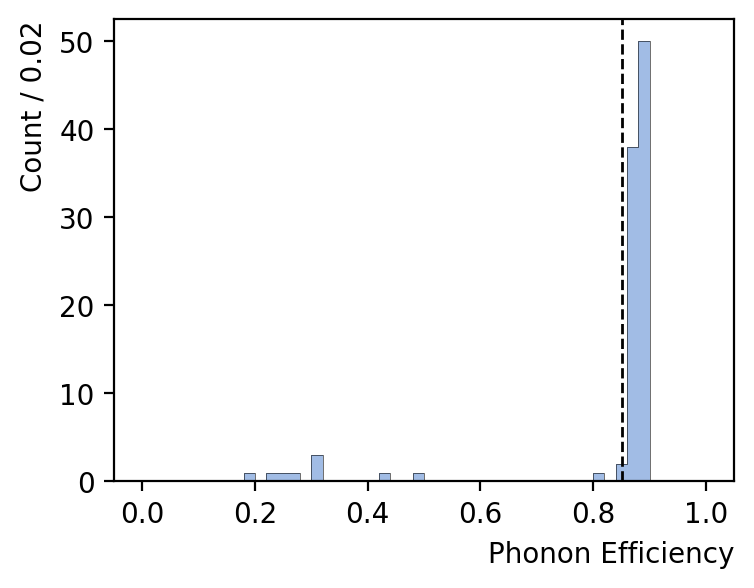

In [157]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(PhononEfficiency, bins = np.linspace(0, 1, 51))
plt.hist(PhononEfficiency, bins = np.linspace(0, 1, 51), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Phonon Efficiency')
plt.ylabel('Count / 0.02')
plt.axvline(0.95 * max(PhononEfficiency), 0, 1, lw = 1, ls = '--', color = 'black')
#plt.text(0.8, 30, 'Efficiency Cutoff', rotation = 90)

We pull in TESSim information for only the events that match our efficiency cut

In [145]:
TESSim = getTES(DMCfiles_nominal, eventMask)

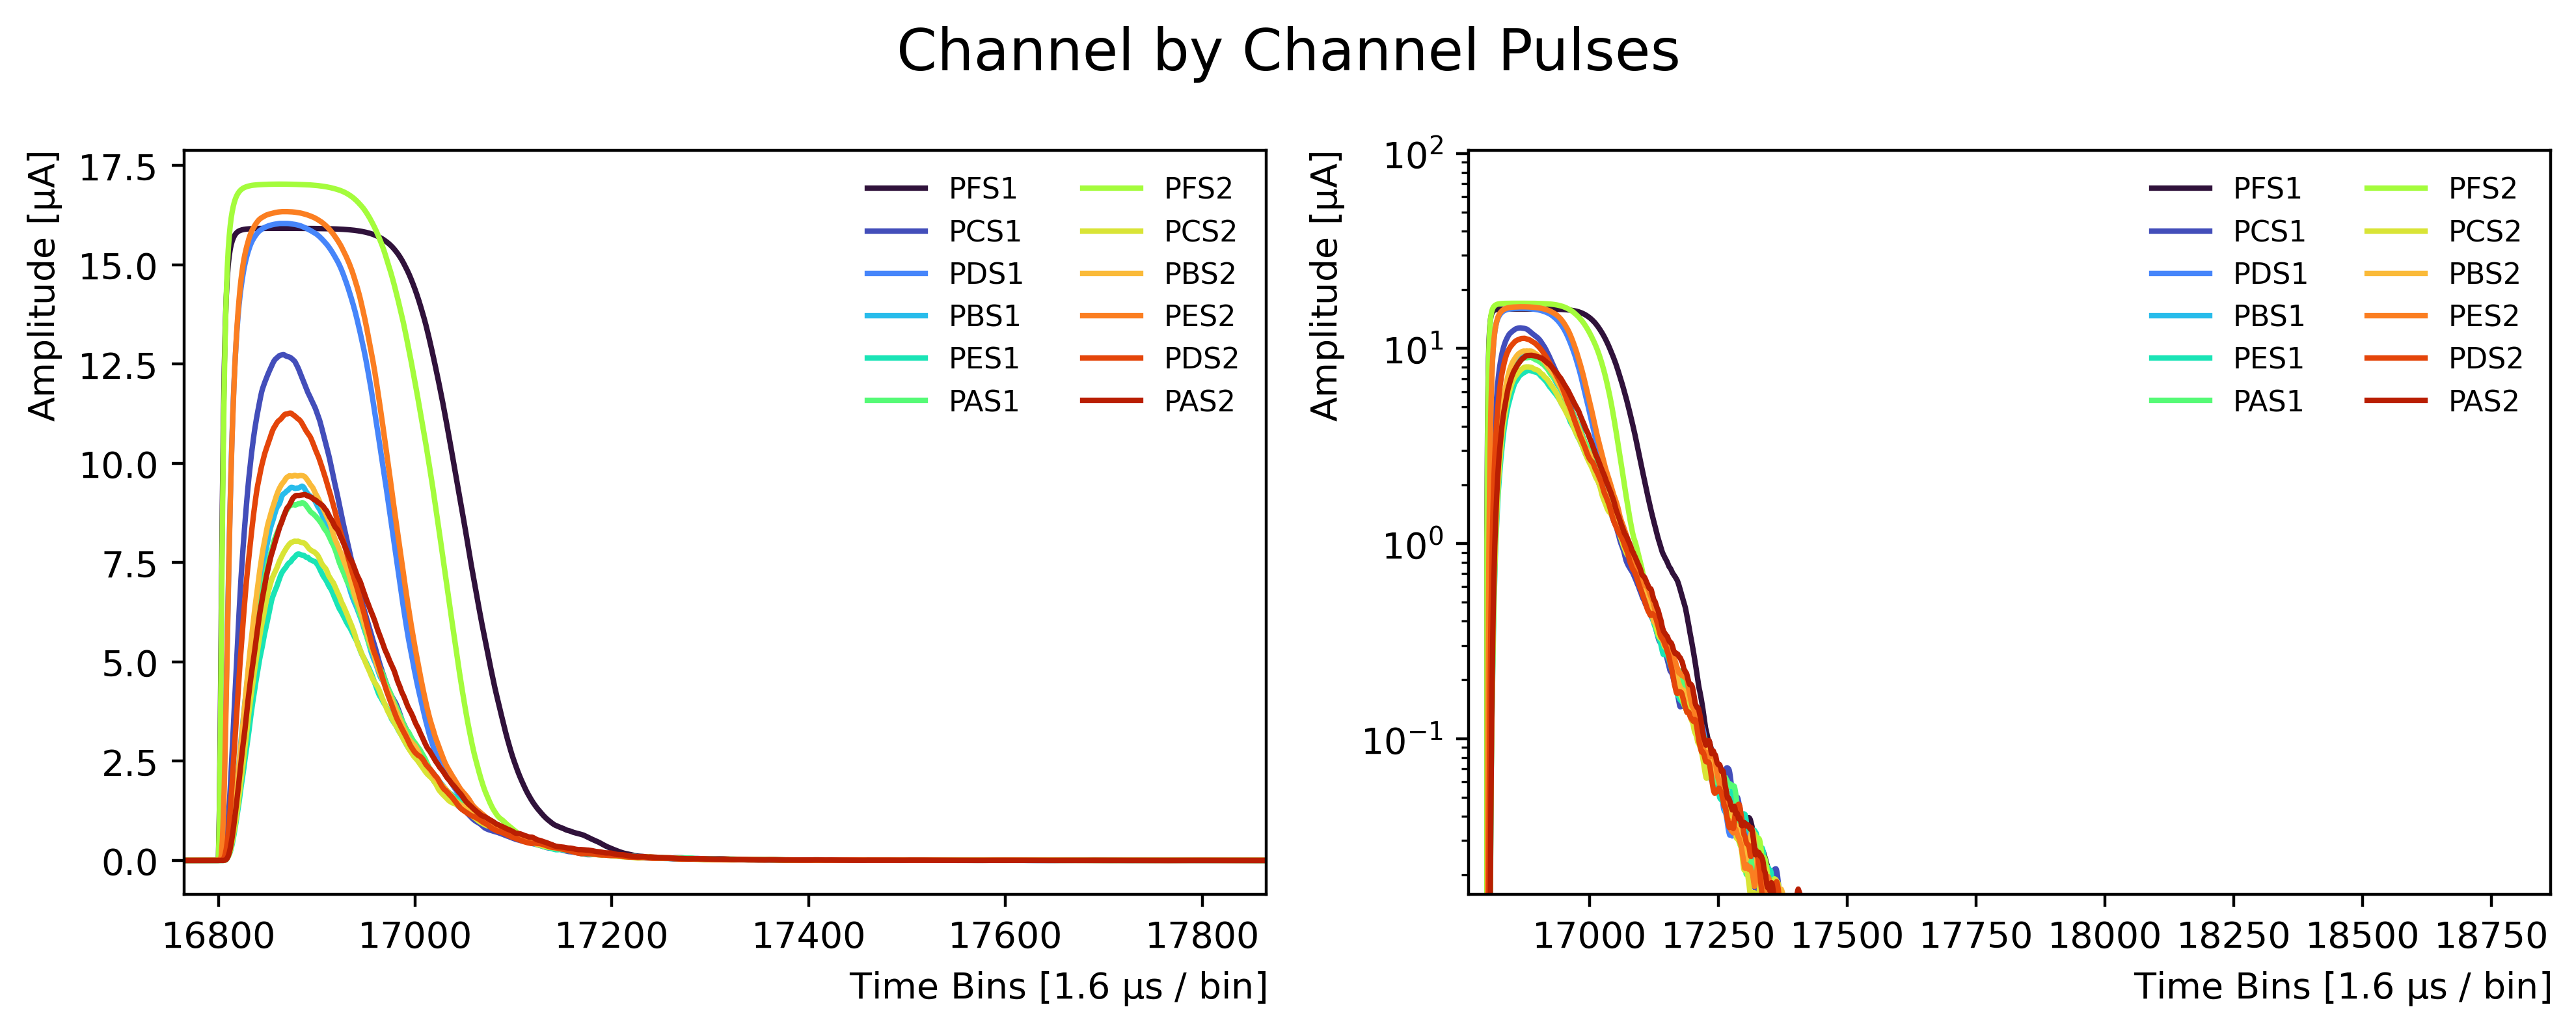

In [146]:
# Let's look at the individual channel pulses for one high efficiency event
eventCut = TESSim['EventNum'] == efficiencyEvents[0]
chanPulses(TESSim['Trace'][eventCut], TESSim['ChanName'][eventCut])

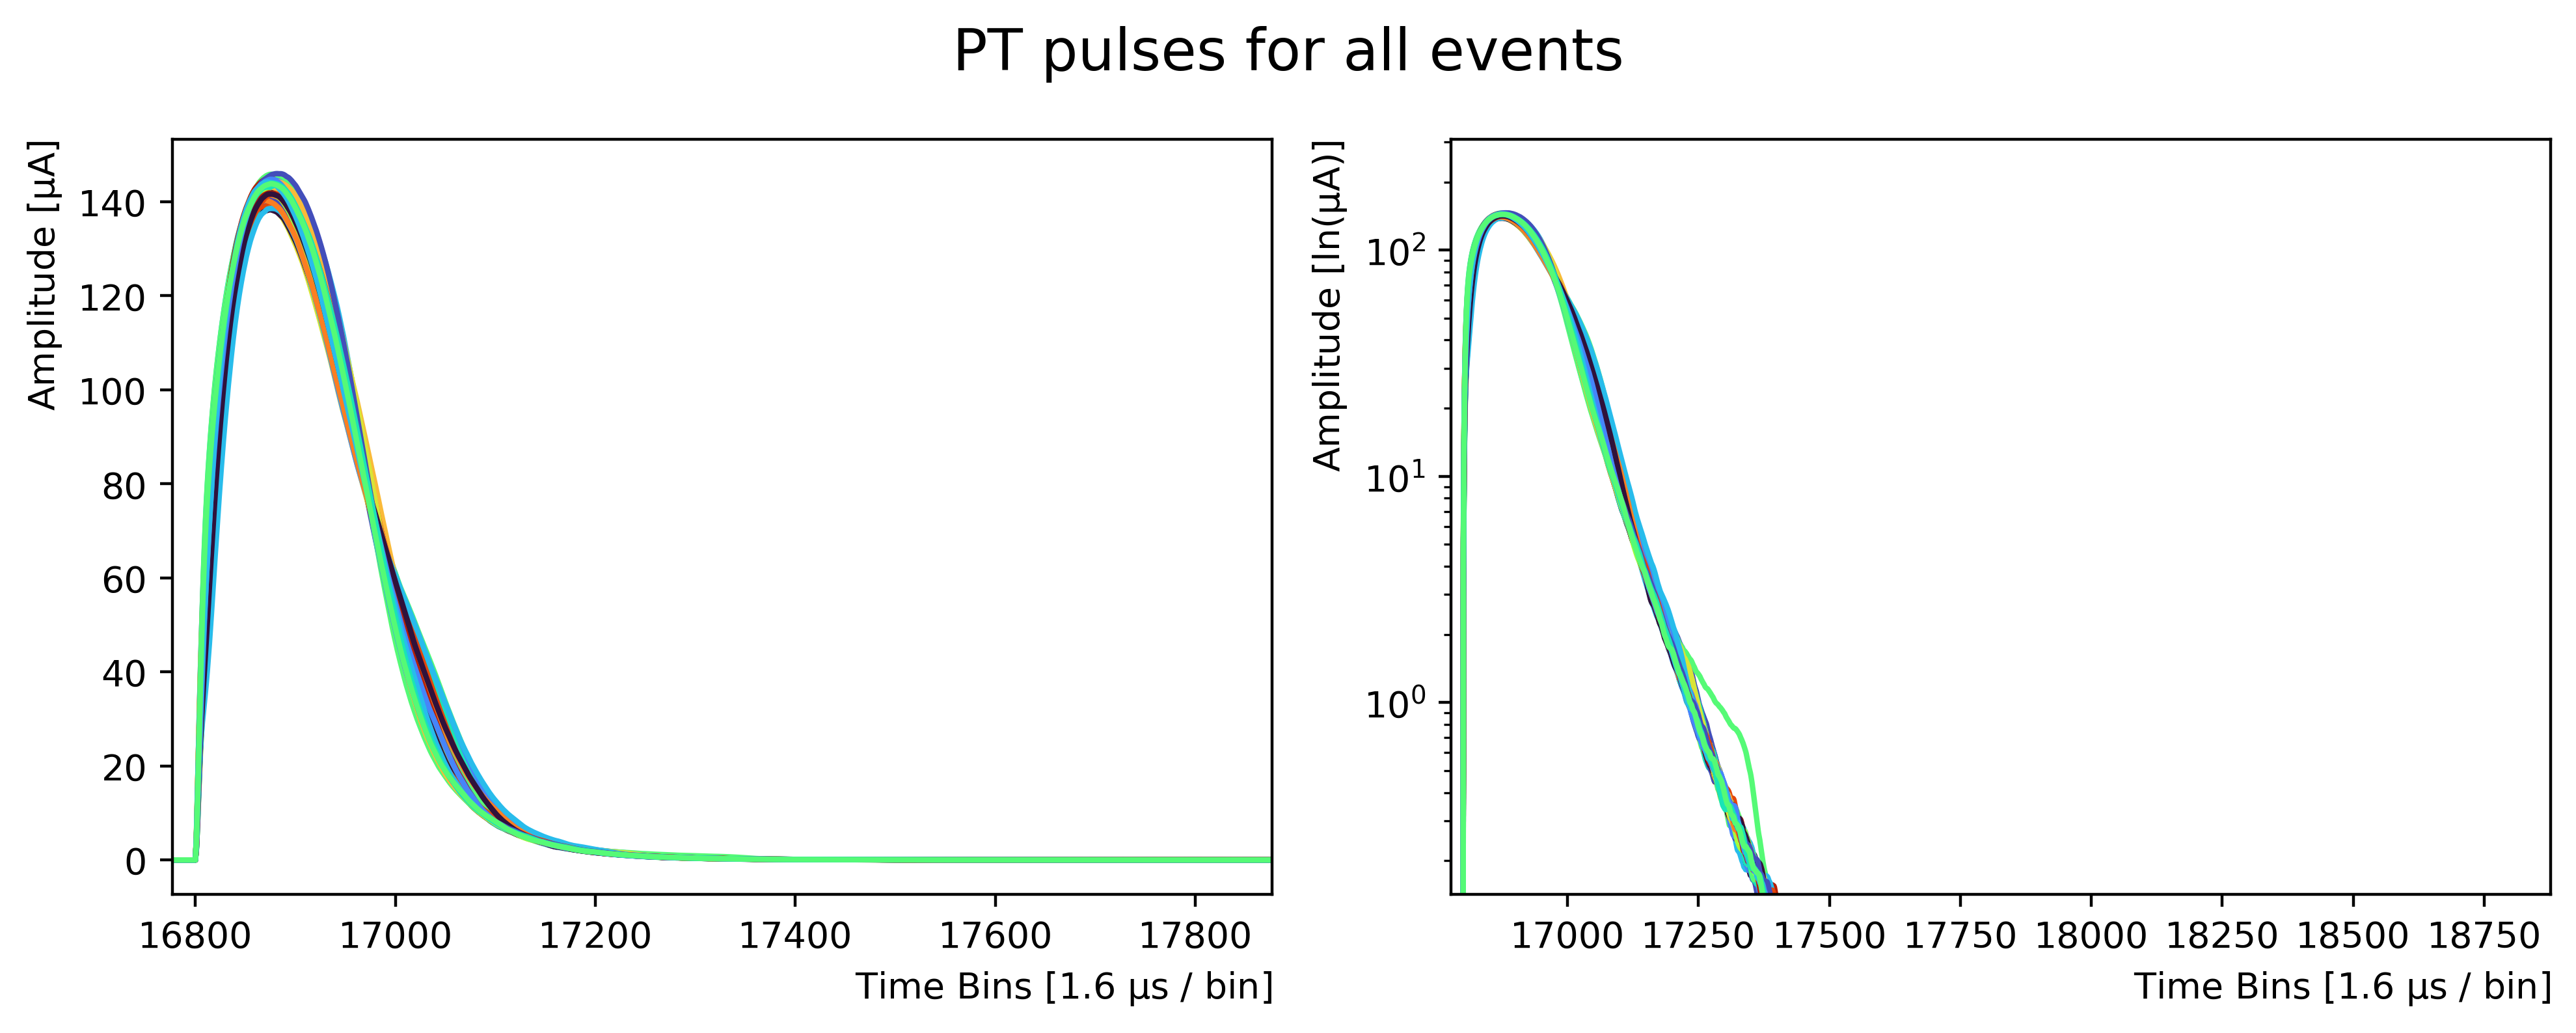

In [147]:
# Let's look at the PT pulse for all high-efficiency events
PTPulses(TESSim['PT'])

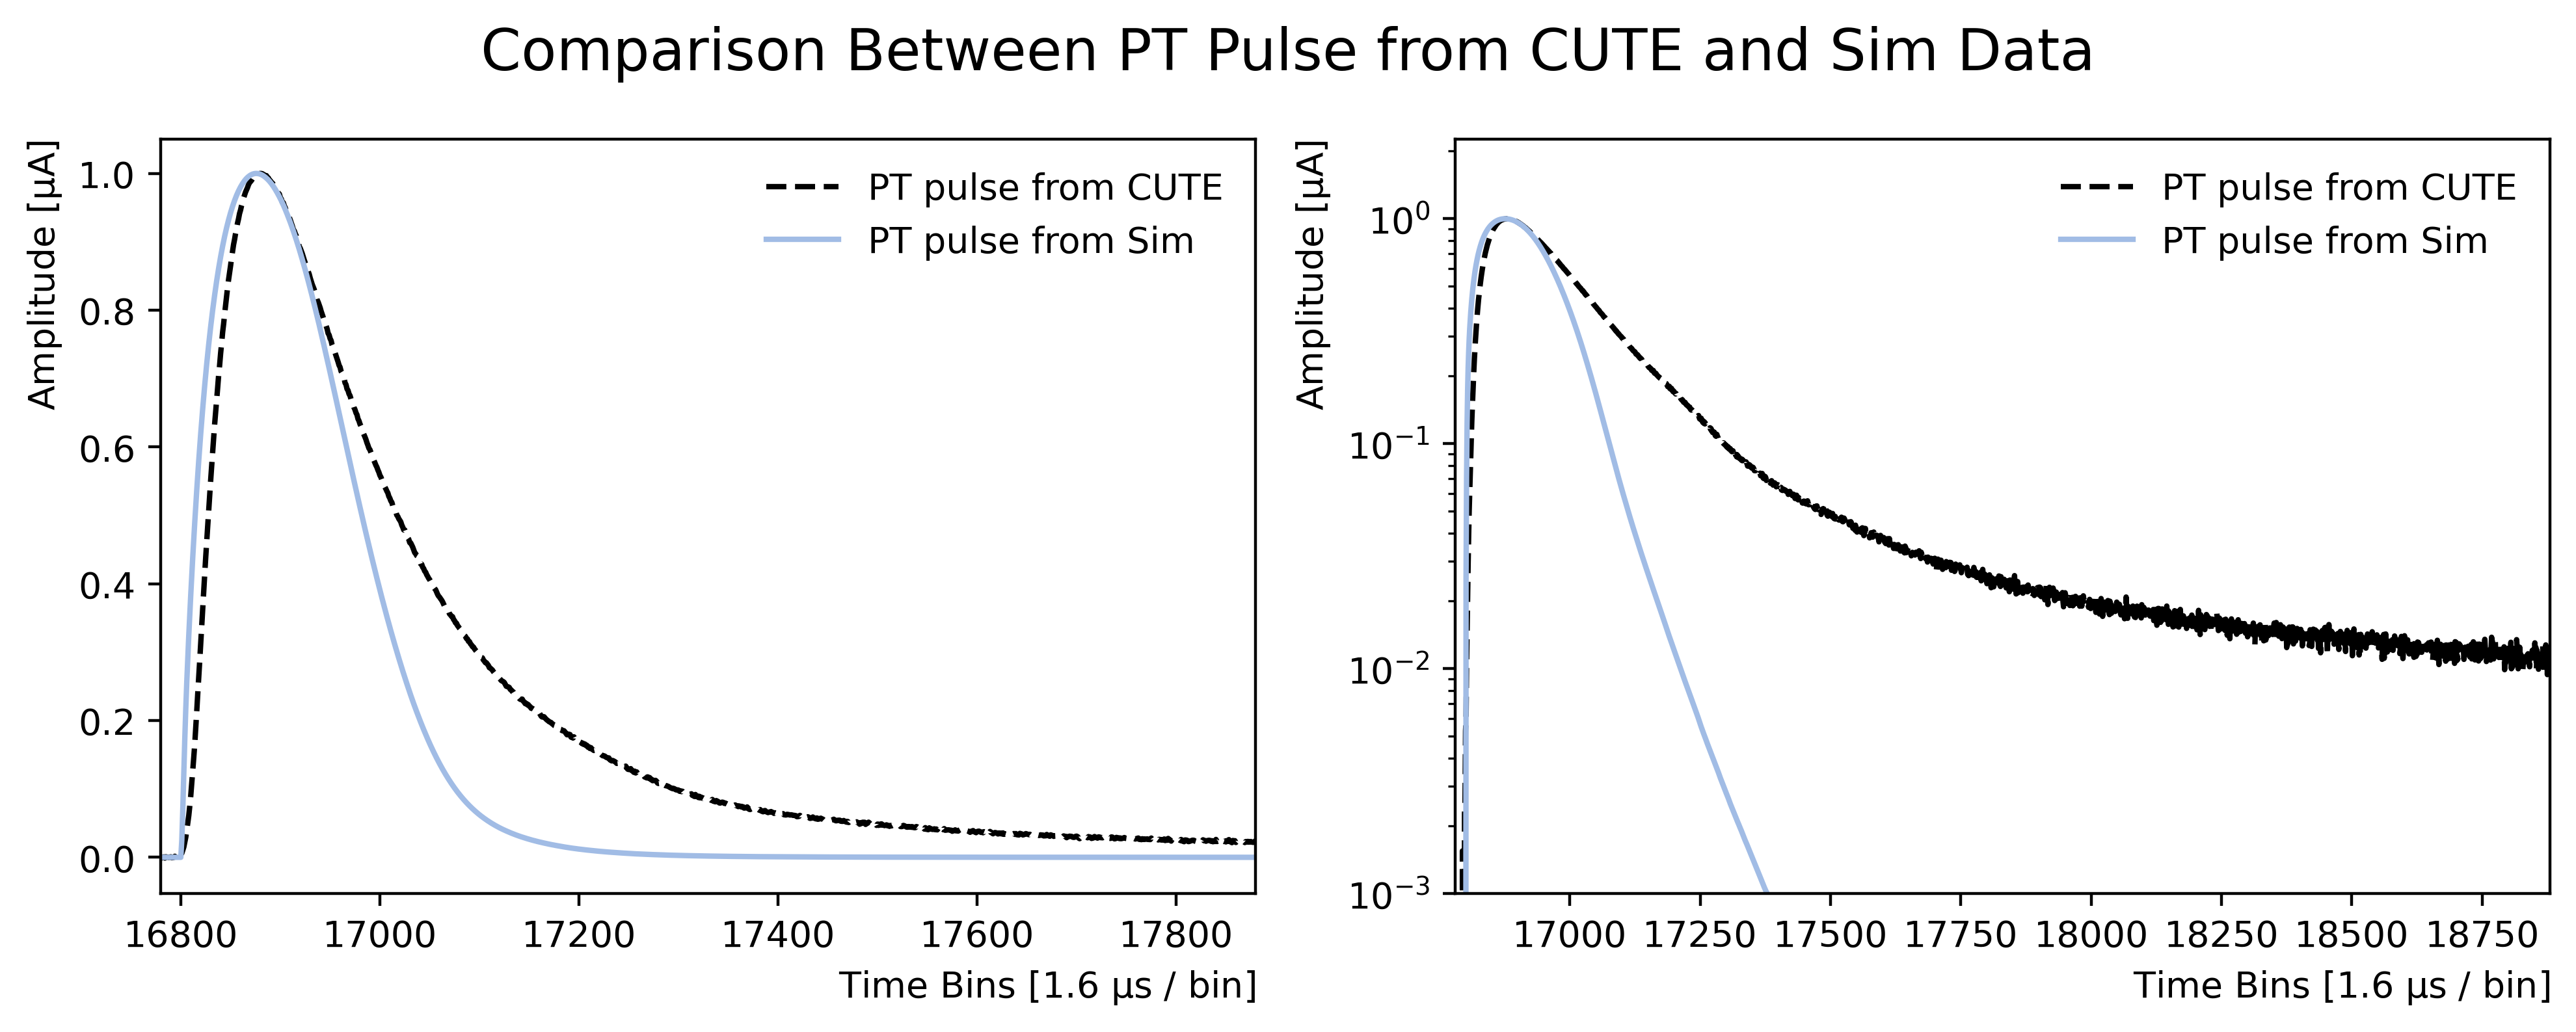

In [148]:
fig, ax = plt.subplots(1, 2, figsize=(5*2, 2*2), dpi = 400)  # 1 row, 2 columns

binshift = 0
timeBins = np.arange(0, len(pulses['PTavg']), 1) + 790 + binshift
maxIndex = pulses['PTavg'].tolist().index(max(pulses['PTavg'])) + 790 + binshift

ax[0].plot(timeBins, pulses['PTavg'], color = 'black', ls = '--', label = 'PT pulse from CUTE')
ax[0].plot(TESSim['PTavg'], color = 'C0', ls = '-', label = 'PT pulse from Sim')
ax[1].plot(timeBins, pulses['PTavg'], color = 'black', ls = '--', label = 'PT pulse from CUTE')
ax[1].plot(TESSim['PTavg'], color = 'C0', ls = '-', label = 'PT pulse from Sim')
        
ax[0].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
ax[0].set_ylabel(r"Amplitude [$\mathrm{\mu A}$]")
ax[0].set_xlim(maxIndex - 100, maxIndex + 1000)
ax[0].legend()

ax[1].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
ax[1].set_ylabel(r"Amplitude [$\mathrm{\mu A}$]")
ax[1].set_yscale('log')
ax[1].set_xlim(maxIndex - 100, maxIndex + 2000)
ax[1].set_ylim(0.001, None) # set lower y-axis bound by fraction of peak height. Adjust as needed.
ax[1].legend()

fig.suptitle(f'Comparison Between PT Pulse from CUTE and Sim Data', fontsize=16)

plt.tight_layout()

## Surface Mediated Anharmonic Down-Conversion Scan

Let's scan the fifth order coefficient for the surface anharmonic down-conversion probability.<br> We set the probability so that it scales with $A v^5$ where $A$ is the coefficient we are scanning in units of GHz$^{-5}$.

In [149]:
coeffs = [20, 18, 16, 14, 12, 10]
Erecoil, Vbias, Epair = 10300, 50, 2.96
DMCfiles_anh = {coeff: np.sort(glob.glob(f'/lustre06/project/6035200/perry/SimData/HV_Z1/DMCOutput_tuningSamples/HV100mm_G157_Kpeak/anhDecay_1e-{coeff}v5_reorder_????????_??????.root')) for coeff in coeffs}

Below, I've shown the collection efficiency spectra for each anharmonic decay setting. At high probabilities, it's more difficult to separate events which experienced reduced Luke gain from those that didnt. I think for this initial scan, let's ignore the collection efficiency cut.

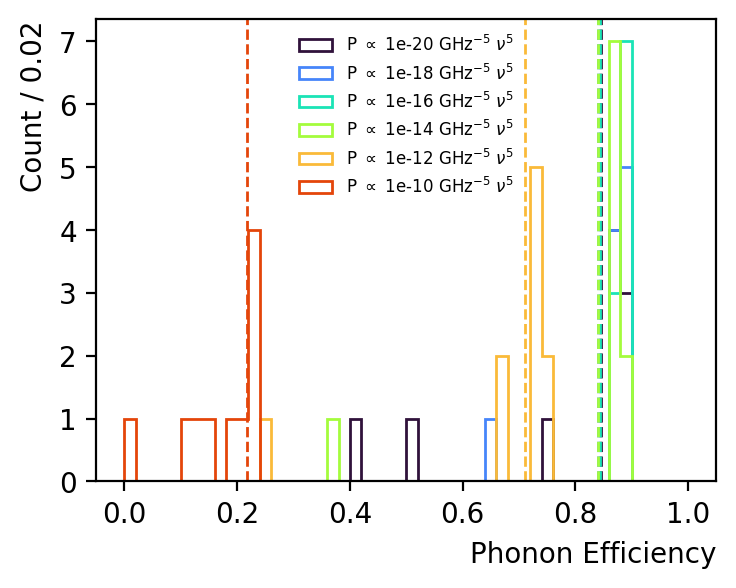

In [150]:
plt.figure(figsize=(4,3), dpi=200)
colors = [colormap(i / len(coeffs)) for i in range(12)]

for i, coeff in enumerate(coeffs):
    
    PhononEfficiency, efficiencyEvents, eventMask = PhononEfficiencyCut(DMCfiles_anh[coeff], Erecoil, Vbias, Epair)
    
    plt.hist(PhononEfficiency, bins = np.linspace(0, 1, 51), histtype='step', color = colors[i], lw = 1, label = r'P $\propto$ 1e-' + str(coeff) + r' GHz$^{-5}$ $\nu^5$')
    plt.axvline(0.95 * max(PhononEfficiency), 0, 1, lw = 1, ls = '--', color = colors[i])

    plt.xlabel('Phonon Efficiency')
    plt.ylabel('Count / 0.02')
    plt.legend(fontsize = 6)

Let's look at the PT pulses of the $P \propto 1\text{e-}10 \,\mathrm{GHz^{-5}} \nu^5$ sample<br>
We see that they peak in the range 60 $\mu$A - 85 $\mu$A (ignoring what looks like a low efficiency event) which is an improvement!

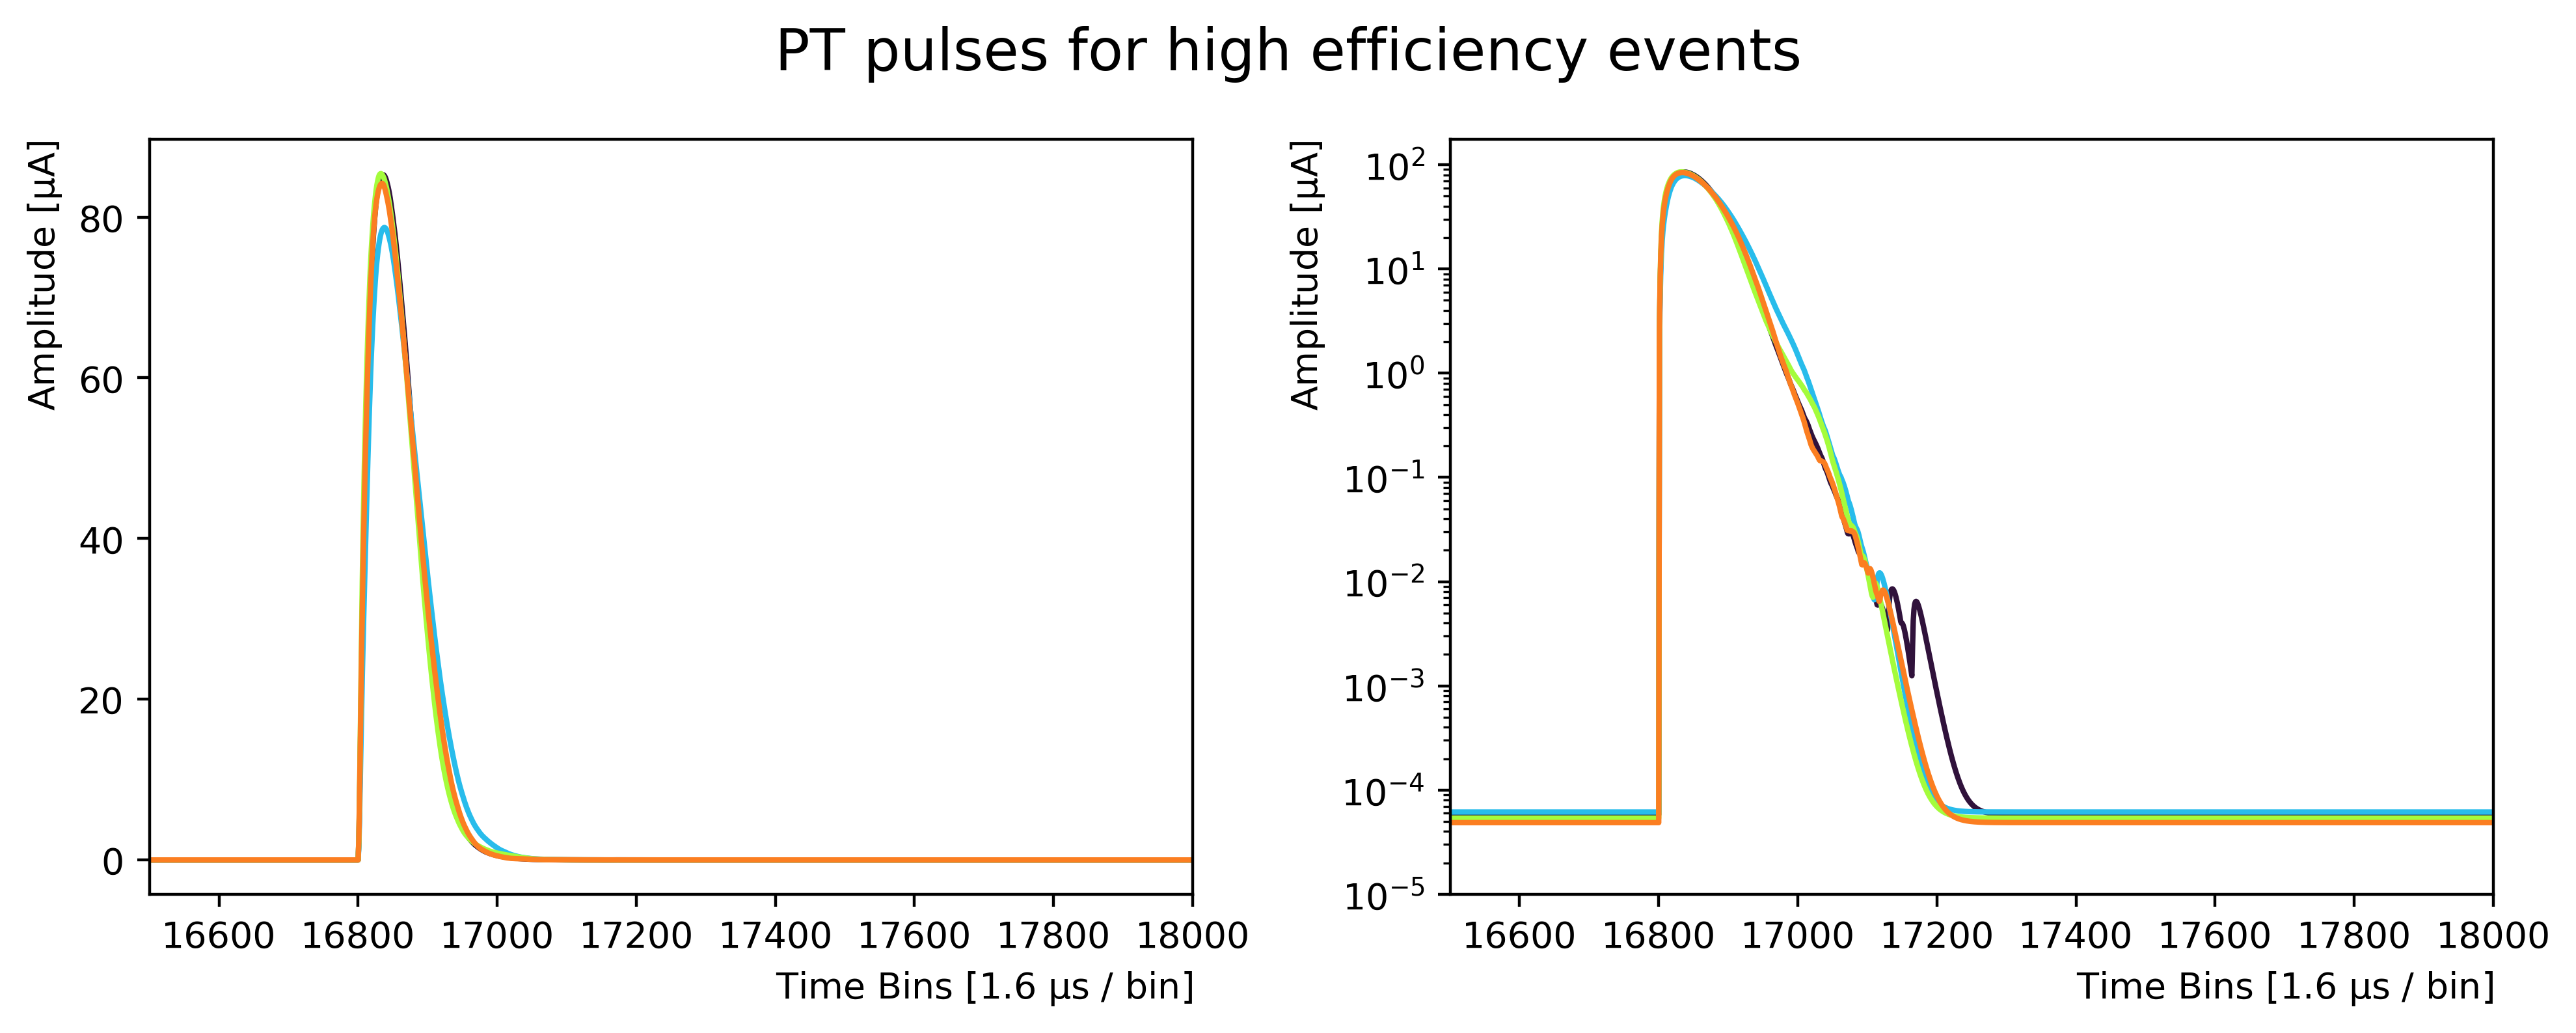

In [151]:
coeff = 10
    
fig, ax = plt.subplots(1, 2, figsize=(5*2, 2*2), dpi = 400)  # 1 row, 2 columns

PhononEfficiency, efficiencyEvents, eventMask = PhononEfficiencyCut(DMCfiles_anh[coeff], Erecoil, Vbias, Epair)
TESSim = getTES(DMCfiles_anh[coeff], eventMask)

colors = [colormap(i / len(TESSim['PT'])) for i in range(len(TESSim['PT']))]

for i, pulse in enumerate(TESSim['PT']):
    ax[0].plot(pulse, color = colors[i % 12])
    ax[1].plot(pulse, color = colors[i % 12])
        
ax[0].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
ax[0].set_ylabel(r"Amplitude [$\mathrm{\mu A}$]")
ax[0].set_xlim(16500, 18000)

ax[1].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
ax[1].set_ylabel(r"Amplitude [$\mathrm{\mu A}$]")
ax[1].set_xlim(16500, 18000)
ax[1].set_yscale('log')
ax[1].set_ylim(1e-5, None)

fig.suptitle(f'PT pulses for high efficiency events', fontsize=16)

plt.tight_layout()

Let's now look at the average PT pulse from each of our samples with different down-conversion settings.<br>
It looks like $P \propto 1\text{e-}10 \,\mathrm{GHz^{-5}} \nu^5$ is the only one that isn't completely saturated. Let's start with this parameter value.

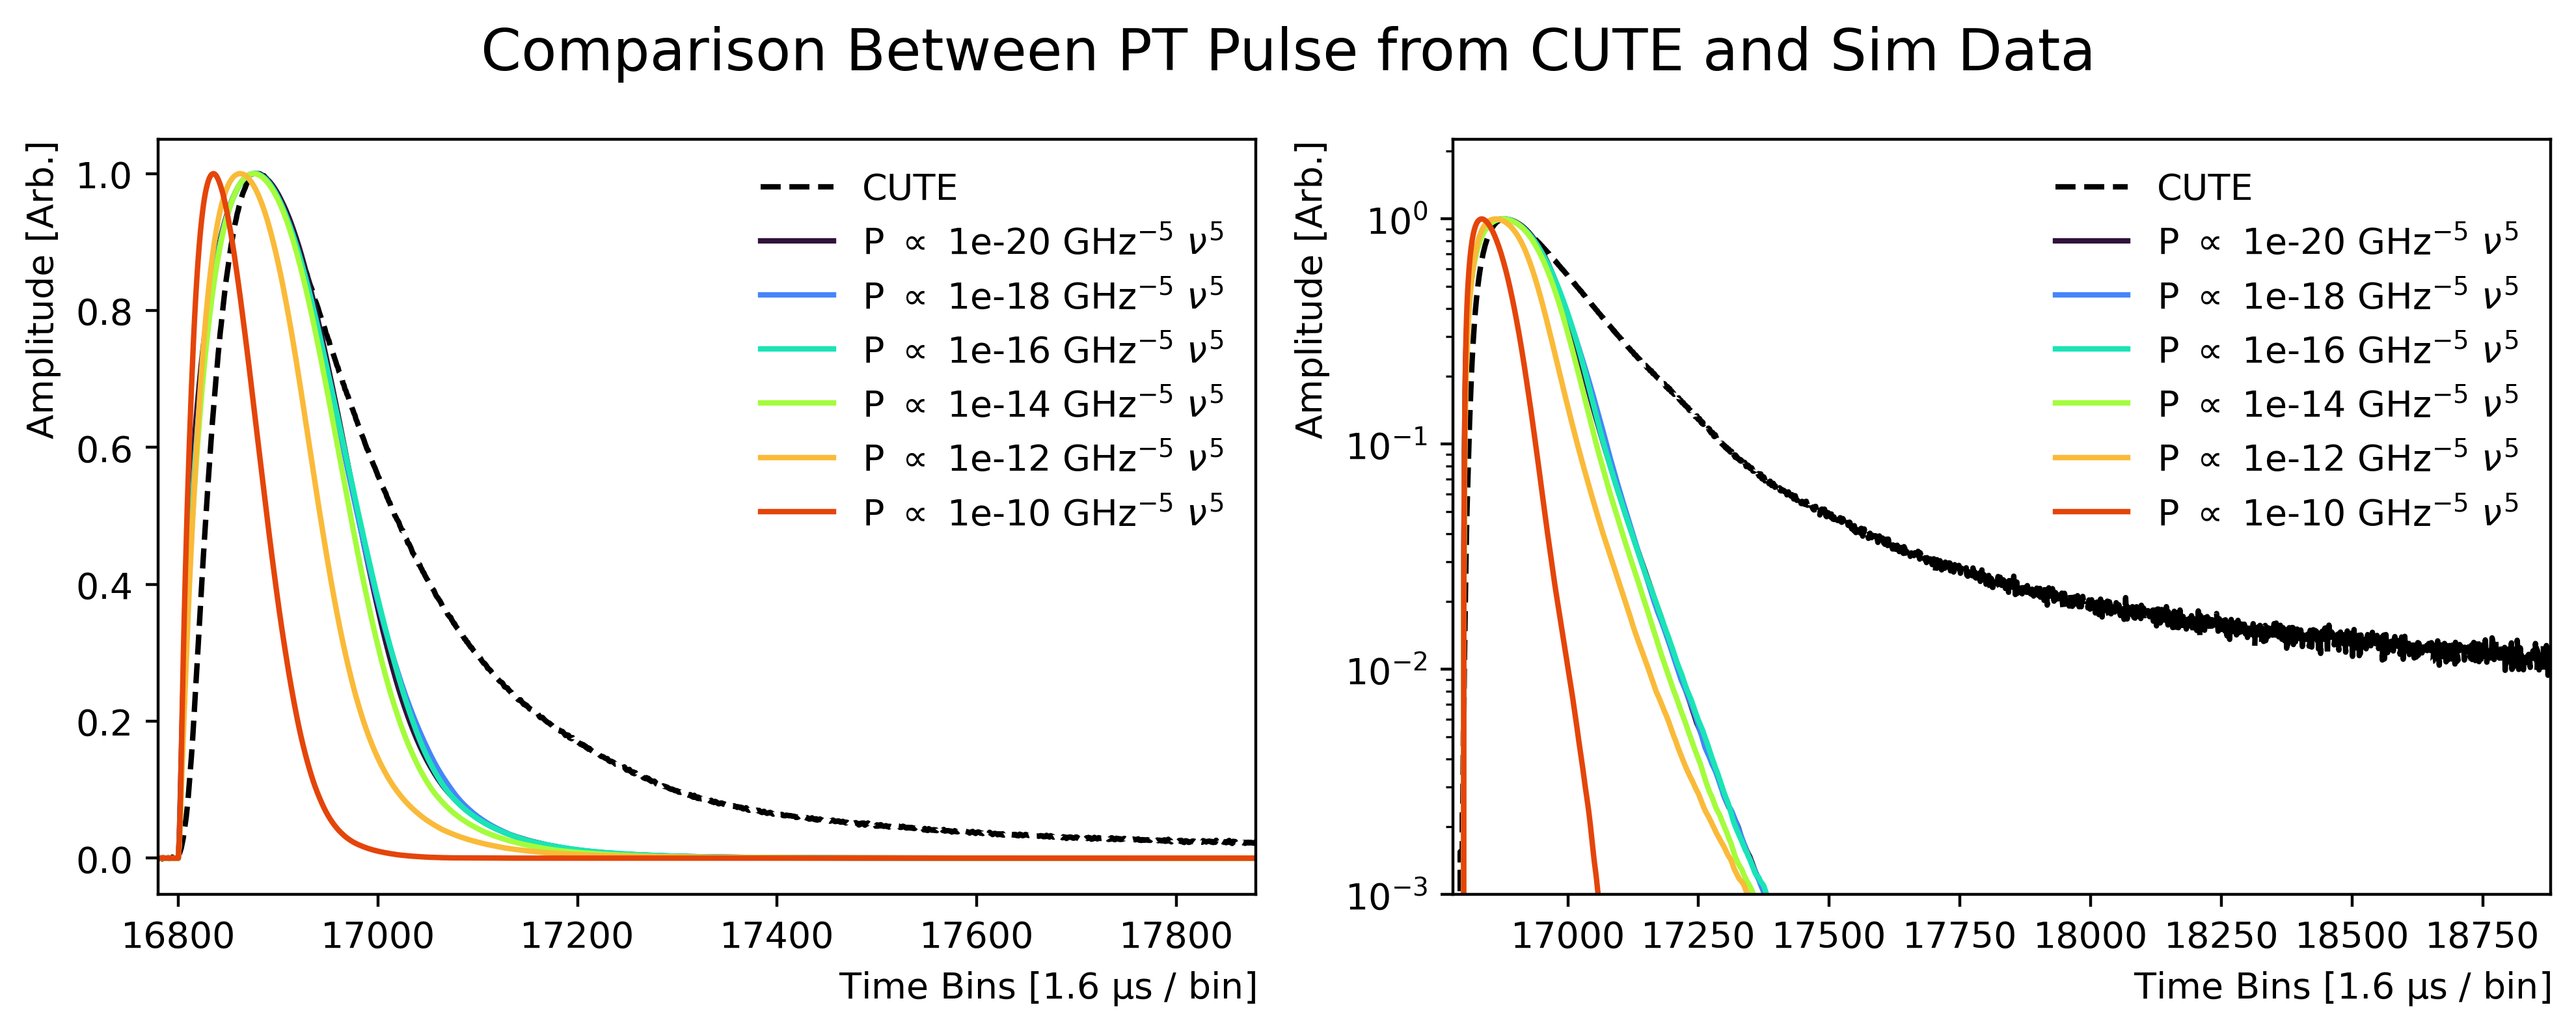

In [152]:
colors = [colormap(i / len(coeffs)) for i in range(len(coeffs))]

fig, ax = plt.subplots(1, 2, figsize=(5*2, 2*2), dpi = 400)  # 1 row, 2 columns

binshift = 0
timeBins = np.arange(0, len(pulses['PTavg']), 1) + 790 + binshift
maxIndex = pulses['PTavg'].tolist().index(max(pulses['PTavg'])) + 790 + binshift

ax[0].plot(timeBins, pulses['PTavg'], color = 'black', ls = '--', label = 'CUTE')
ax[1].plot(timeBins, pulses['PTavg'], color = 'black', ls = '--', label = 'CUTE')

for i, coeff in enumerate(coeffs):
    PhononEfficiency, efficiencyEvents, eventMask = PhononEfficiencyCut(DMCfiles_anh[coeff], Erecoil, Vbias, Epair)
    TESSim = getTES(DMCfiles_anh[coeff], eventMask)

    ax[0].plot(TESSim['PTavg'], color = colors[i], label = r'P $\propto$ 1e-' + str(coeff) + r' GHz$^{-5}$ $\nu^5$')
    ax[1].plot(TESSim['PTavg'], color = colors[i], label = r'P $\propto$ 1e-' + str(coeff) + r' GHz$^{-5}$ $\nu^5$')
        
ax[0].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
ax[0].set_ylabel(r"Amplitude [Arb.]")
ax[0].set_xlim(maxIndex - 100, maxIndex + 1000)
ax[0].legend()

ax[1].set_xlabel(r'Time Bins [1.6 $\mathrm{\mu}$s / bin]')
ax[1].set_ylabel(r"Amplitude [Arb.]")
ax[1].set_yscale('log')
ax[1].set_xlim(maxIndex - 100, maxIndex + 2000)
ax[1].set_ylim(0.001, None) # Adjust as needed.
ax[1].legend()

fig.suptitle(f'Comparison Between PT Pulse from CUTE and Sim Data', fontsize=16)

plt.tight_layout()